In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.cm as cm
from matplotlib.colors import LogNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyhdf.SD import SD, SDC
import math
import pprint

import glob
import re
import sys, os, glob, datetime
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [2]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/" \
        "PACE_OCI.20240501_20240531.L3m.MO.CLOUD.V3_1.1deg.nc"
print(path)

dataset = xr.open_dataset(path)

OCI_CER = dataset['cer_21_water']


path_H = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/" \
        "PACE_HARP2.20240501_20240531.L3m.MO.CLOUD_GPC.V3_0.1deg.nc"
print(path_H)

dataset_H = xr.open_dataset(path_H)

HARP2_CER = dataset_H['cloud_bow_droplet_effective_radius']


mask_all = (HARP2_CER > 0) & (OCI_CER > 0)

/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/PACE_OCI.20240501_20240531.L3m.MO.CLOUD.V3_1.1deg.nc
/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/PACE_HARP2.20240501_20240531.L3m.MO.CLOUD_GPC.V3_0.1deg.nc


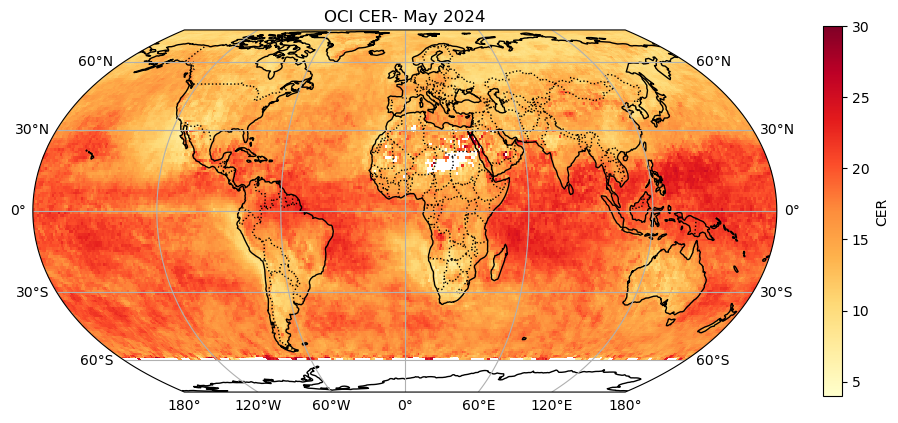

In [3]:
lon = dataset['lon']
lat = dataset['lat']
data_CER= OCI_CER.where(mask_all)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, data_CER, shading="nearest", rasterized=True, 
                    transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=4, vmax=30,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('OCI CER- May 2024')  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.6,)    
cbar.set_label('CER')

# plt.tight_layout()
# plt.savefig('CER.png', dpi=500, bbox_inches="tight")

plt.show()

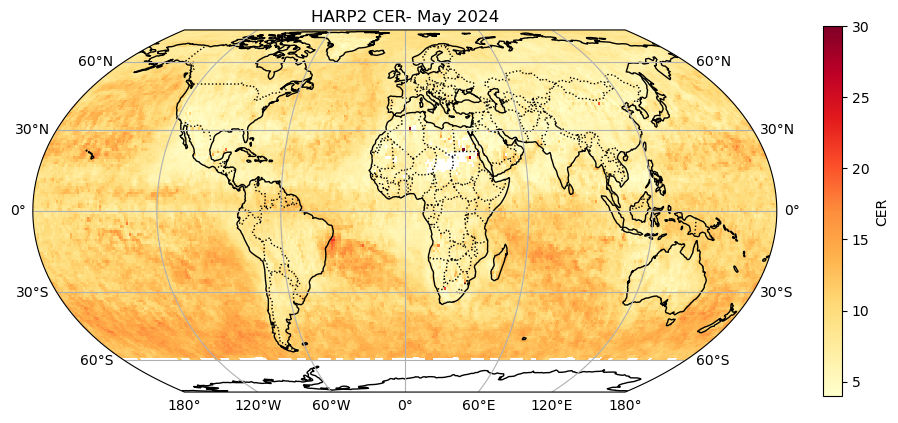

In [4]:
data_HARP2= HARP2_CER.where(mask_all)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, data_HARP2, shading="nearest", rasterized=True, 
                    transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=4, vmax=30,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CER- May 2024')  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.6,)    
cbar.set_label('CER')

# plt.tight_layout()
# plt.savefig('CER.png', dpi=500, bbox_inches="tight")

plt.show()

scale factor: 0.009999999776482582
Max and Min CER is: 28.999999351799488 -99.98999776504934


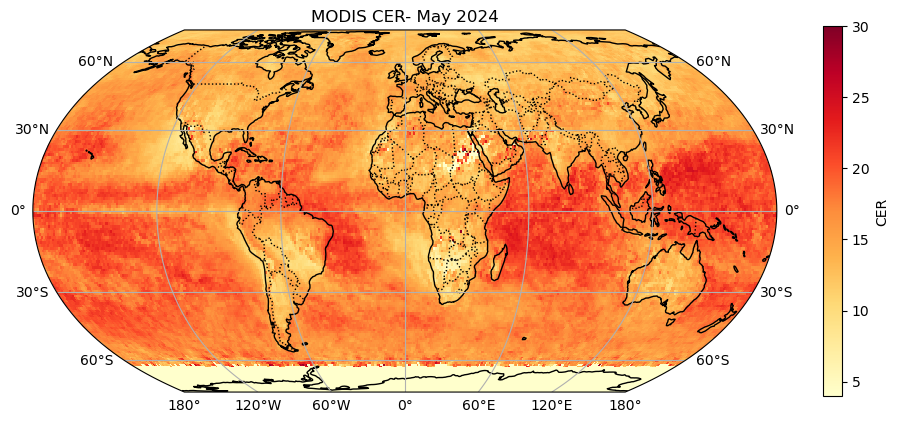

In [5]:
# Load HDF4 file
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cer = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')   
cer_data = cer.get()

m_scal = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cer.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cer1 = cer_data*scale
print('Max and Min CER is:', np.max(cer1), np.min(cer1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cer1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), 
                    cmap='YlOrRd', vmin=4, vmax=30,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('MODIS CER- May 2024')  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.6,)    
cbar.set_label('CER')

# plt.tight_layout()
# plt.savefig('CER.png', dpi=500, bbox_inches="tight")

plt.show()

scale factor: 0.009999999776482582
Max and Min CER is: 29.869999332353473 -99.98999776504934


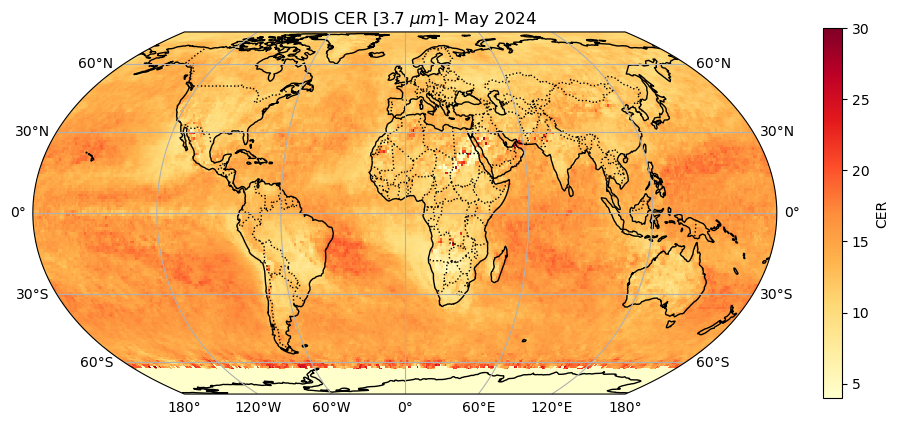

In [6]:
# Load HDF4 file
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)
mydata_SDSs= my_data.datasets()
# for idx, sds in enumerate(mydata_SDSs.keys()):
#     print(idx,sds)

sds_attr1 = my_data.select('Cloud_Effective_Radius_37_Liquid_Mean_Mean')      
# pprint.pprint(sds_attr1.attributes())

cer = my_data.select('Cloud_Effective_Radius_37_Liquid_Mean_Mean')   
cer_data = cer.get()

m_scal = my_data.select('Cloud_Effective_Radius_37_Liquid_Mean_Mean')
m_scal_val = m_scal.get()
attributes = cer.attributes()
scale = attributes.get('scale_factor')
print('scale factor:', scale)

rgb = np.zeros((203,135,1))
cer1 = cer_data*scale
print('Max and Min CER is:', np.max(cer1), np.min(cer1))

lat = np.arange(90,-91,-1)
lon = np.arange(-180,181)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(lon, lat, cer1, shading="nearest", rasterized=True, transform=ccrs.PlateCarree(), 
                    cmap='YlOrRd', vmin=4, vmax=30,) 

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title(r'MODIS CER [3.7 $\mu m$]- May 2024')  

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.6,)    
cbar.set_label('CER')

# plt.tight_layout()
# plt.savefig('CER.png', dpi=500, bbox_inches="tight")

plt.show()

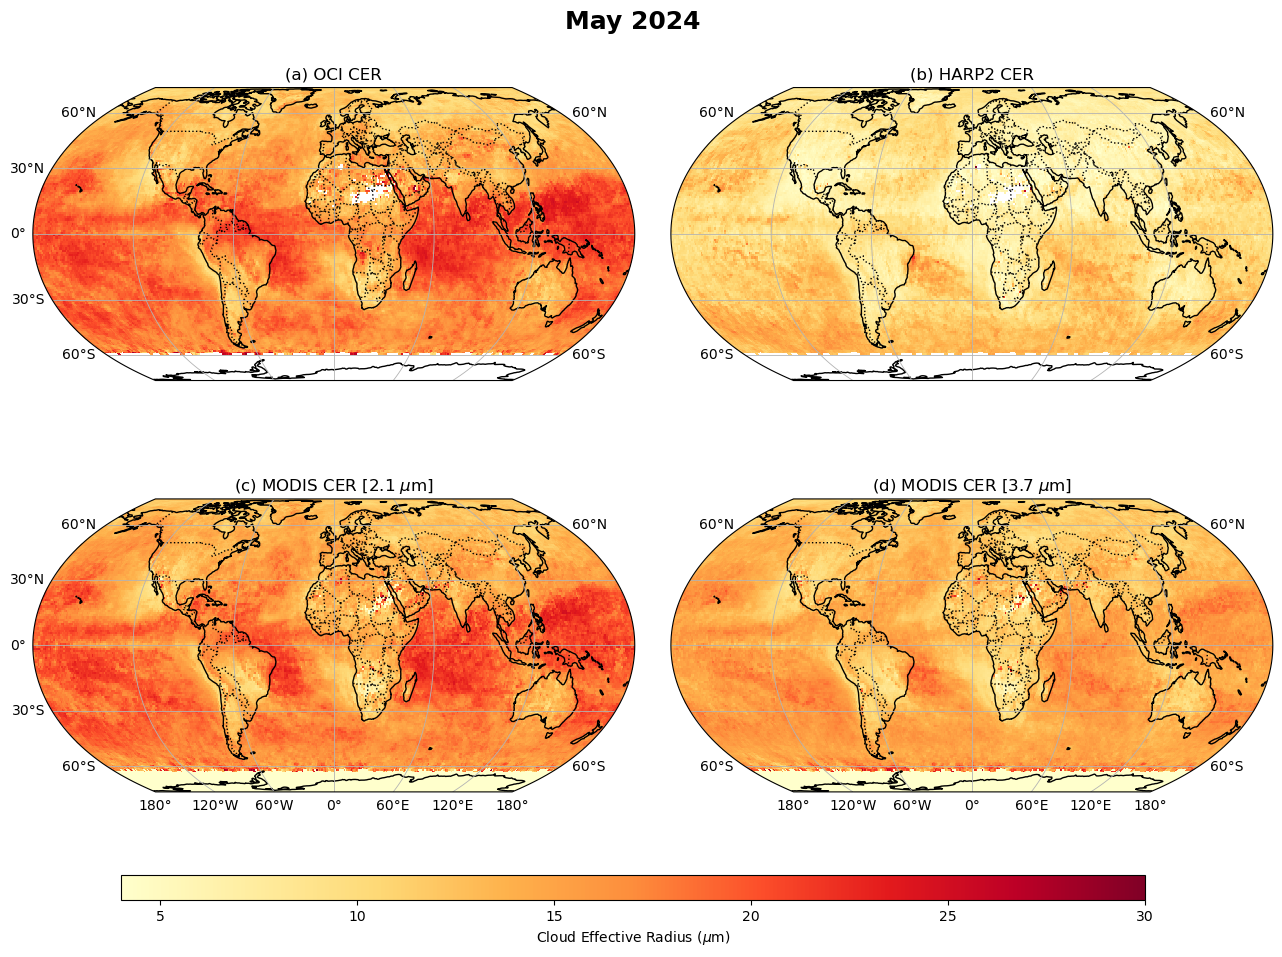

In [7]:
# -----------------------
# LOAD PACE DATA
# -----------------------
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/" \
       "PACE_OCI.20240501_20240531.L3m.MO.CLOUD.V3_1.1deg.nc"
dataset = xr.open_dataset(path)
OCI_CER = dataset['cer_21_water']

path_H = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/" \
         "PACE_HARP2.20240501_20240531.L3m.MO.CLOUD_GPC.V3_0.1deg.nc"
dataset_H = xr.open_dataset(path_H)
HARP2_CER = dataset_H['cloud_bow_droplet_effective_radius']

mask_all = (HARP2_CER > 0) & (OCI_CER > 0)

lon_pace = dataset['lon']
lat_pace = dataset['lat']

OCI_plot = OCI_CER.where(mask_all)
HARP2_plot = HARP2_CER.where(mask_all)

# -----------------------
# LOAD MODIS DATA
# -----------------------
mod_data = 'MOD08_M3.A2024122.061.2024162163356.hdf'
my_data = SD(mod_data, SDC.READ)

# MODIS 2.1 µm
cer21 = my_data.select('Cloud_Effective_Radius_Liquid_Mean_Mean')
cer21_data = cer21.get()
scale21 = cer21.attributes().get('scale_factor')
MODIS_21 = cer21_data * scale21

# MODIS 3.7 µm
cer37 = my_data.select('Cloud_Effective_Radius_37_Liquid_Mean_Mean')
cer37_data = cer37.get()
scale37 = cer37.attributes().get('scale_factor')
MODIS_37 = cer37_data * scale37

lat_modis = np.arange(90, -91, -1)
lon_modis = np.arange(-180, 181)

# -----------------------
# FIGURE
# -----------------------
fig, axes = plt.subplots(
    2, 2, figsize=(16, 10),
    subplot_kw={'projection': ccrs.EqualEarth()}
)

vmin, vmax = 4, 30
cmap = 'YlOrRd'

def format_map(ax, show_left=False, show_bottom=False):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        linewidth=0.6,
        color='0.7'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left
    gl.bottom_labels = show_bottom
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

# -----------------------
# (a) OCI
# -----------------------
ax = axes[0, 0]
img = ax.pcolormesh(
    lon_pace, lat_pace, OCI_plot,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title(r'(a) OCI CER')
format_map(ax, show_left=True, show_bottom=False)

# -----------------------
# (b) HARP2
# -----------------------
ax = axes[0, 1]
ax.pcolormesh(
    lon_pace, lat_pace, HARP2_plot,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title('(b) HARP2 CER')
format_map(ax, show_left=False, show_bottom=False)

# -----------------------
# (c) MODIS 2.1 µm
# -----------------------
ax = axes[1, 0]
ax.pcolormesh(
    lon_modis, lat_modis, MODIS_21,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title(r'(c) MODIS CER [2.1 $\mu$m]')
format_map(ax, show_left=True, show_bottom=True)

# -----------------------
# (d) MODIS 3.7 µm
# -----------------------
ax = axes[1, 1]
ax.pcolormesh(
    lon_modis, lat_modis, MODIS_37,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title(r'(d) MODIS CER [3.7 $\mu$m]')
format_map(ax, show_left=False, show_bottom=True)

# Leave room at bottom for shared colorbar
fig.subplots_adjust(top=0.92, bottom=0.16, wspace=0.06, hspace=0.18)

# Proper shared colorbar below all panels
cbar_ax = fig.add_axes([0.18, 0.08, 0.64, 0.025])   # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cloud Effective Radius ($\mu$m)')
cbar.ax.tick_params(labelsize=10)
fig.suptitle('May 2024', fontsize=18, fontweight='bold', y=0.97)

plt.savefig('CER.png', dpi=500, bbox_inches="tight")
plt.show()

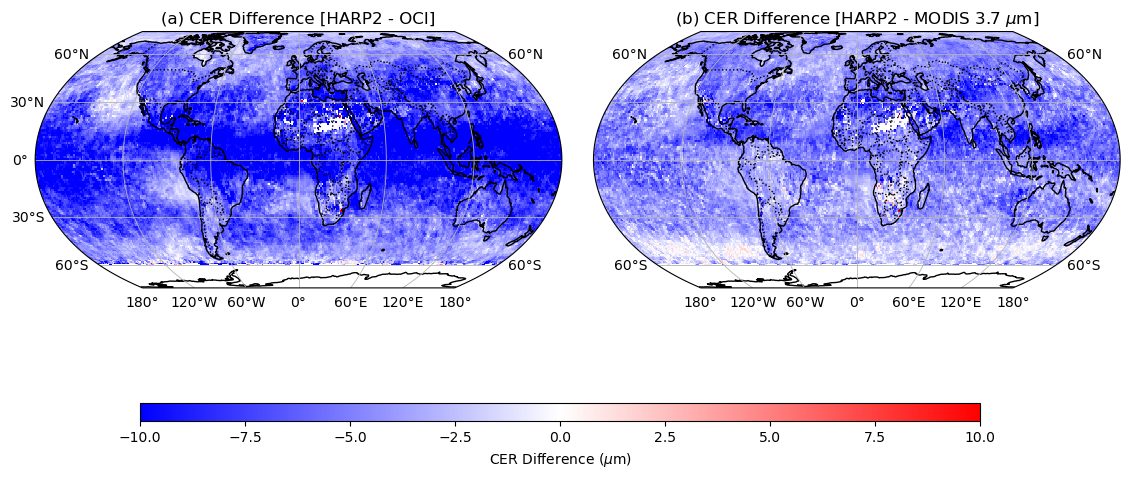

In [8]:
# -----------------------
# MAKE MODIS 3.7 DataArray ON CORRECT GRID
# -----------------------
lat_modis = np.arange(89.5, -90, -1)       # 180 points
lon_modis = np.arange(-179.5, 180, 1)      # 360 points

MODIS_37_da = xr.DataArray(
    MODIS_37,
    coords={'lat': lat_modis, 'lon': lon_modis},
    dims=['lat', 'lon']
)

# Interpolate MODIS 3.7 to PACE/HARP2 grid
MODIS_37_interp = MODIS_37_da.interp(
    lat=lat_pace,
    lon=lon_pace
)

# -----------------------
# DIFFERENCES
# -----------------------
# (a) HARP2 - OCI
diff_OCI = HARP2_plot - OCI_plot

# (b) HARP2 - MODIS 3.7
mask_modis = (HARP2_plot > 0) & (MODIS_37_interp > 0)
diff_MODIS37 = xr.where(mask_modis, HARP2_plot - MODIS_37_interp, np.nan)

# -----------------------
# PLOTTING
# -----------------------
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5.8),
    subplot_kw={'projection': ccrs.EqualEarth()}
)

cmap = 'bwr'
vmin, vmax = -10, 10

def format_map(ax, show_left=False, show_bottom=True):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(
        draw_labels=True, dms=True,
        x_inline=False, y_inline=False,
        linewidth=0.6, color='0.7'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_left
    gl.bottom_labels = show_bottom
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

# (a) HARP2 - OCI
ax = axes[0]
img = ax.pcolormesh(
    lon_pace, lat_pace, diff_OCI,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title('(a) CER Difference [HARP2 - OCI]')
format_map(ax, show_left=True, show_bottom=True)

# (b) HARP2 - MODIS 3.7
ax = axes[1]
ax.pcolormesh(
    lon_pace, lat_pace, diff_MODIS37,
    transform=ccrs.PlateCarree(),
    cmap=cmap, vmin=vmin, vmax=vmax,
    shading='auto',
    rasterized=True
)
ax.set_title(r'(b) CER Difference [HARP2 - MODIS 3.7 $\mu$m]')
format_map(ax, show_left=False, show_bottom=True)

# Shared colorbar below both panels
fig.subplots_adjust(bottom=0.18, wspace=0.06)
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
cbar = fig.colorbar(img, cax=cbar_ax, orientation='horizontal',)
cbar.set_label('CER Difference ($\mu$m)')

plt.show()

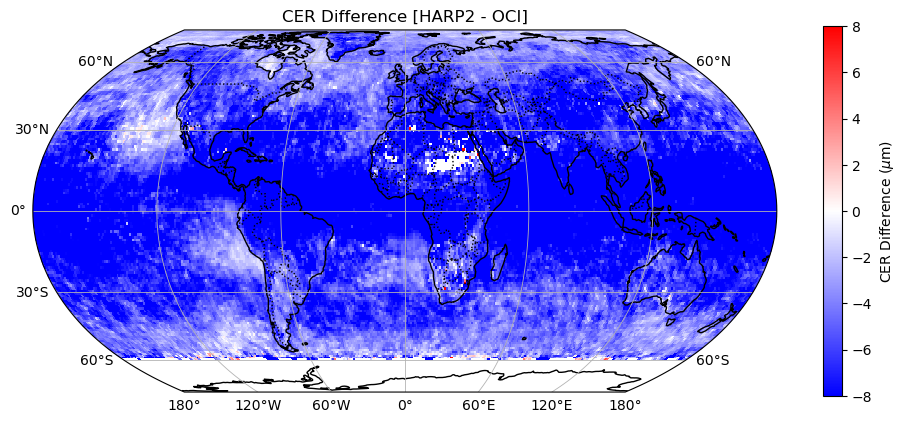

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(
    lon_pace, lat_pace, diff_OCI,
    transform=ccrs.PlateCarree(),
    cmap='bwr', vmin=-8, vmax=8, shading="nearest", rasterized=True
)

ax.set_title('CER Difference [HARP2 - OCI]',)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(
    draw_labels=True, dms=True,
    x_inline=False, y_inline=False,
    linewidth=0.6, color='0.7'
)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, shrink=0.6, pad=0.05)
cbar.set_label('CER Difference ($\\mu$m)')

plt.savefig('CER_diff1.png', dpi=500, bbox_inches="tight")
plt.show()

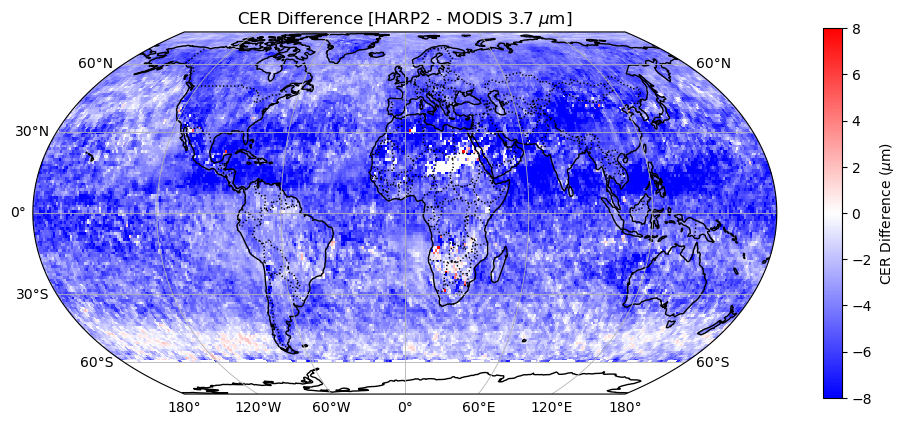

In [10]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.EqualEarth())

img = ax.pcolormesh(
    lon_pace, lat_pace, diff_MODIS37,
    transform=ccrs.PlateCarree(),
    cmap='bwr', vmin=-8, vmax=8,
)

ax.set_title(r'CER Difference [HARP2 - MODIS 3.7 $\mu$m]',)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')

gl = ax.gridlines(
    draw_labels=True, dms=True,
    x_inline=False, y_inline=False,
    linewidth=0.6, color='0.7'
)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, shrink=0.6, pad=0.05)
cbar.set_label('CER Difference ($\\mu$m)')

plt.savefig('CER_diff2.png', dpi=500, bbox_inches="tight")
plt.show()